In [1]:


import torch
from torch import nn
import numpy as np

import matplotlib.pyplot as plt
import numpy as np
import imageio

from sklearn.datasets import make_moons

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device=device)

In [3]:

def sample_checkerboard(batch_size):
    x1 = torch.rand(batch_size) * 4 - 2
  
    x2_ = torch.rand(batch_size) - torch.randint(0, 2, (batch_size,), dtype=torch.float) * 2
    x2 = (x2_ + (torch.floor(x1) % 2))
    
    data = (torch.stack([x1, x2], dim=1) * 2.0 )
    return data

def sample_gauss(batch_size, sigma=1.0):
    return sigma * torch.randn(batch_size, 2)

In [4]:
class VectorFieldNetwork(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = t.view(-1, 1).expand(x.shape[0], 1)
        x_input = torch.cat([x, t_embed], dim=1)
        return self.net(x_input)
    
    def step(self, x_t: torch.Tensor, t_start: torch.Tensor, t_end: torch.Tensor):
        t_start = t_start.view(1,1 ).expand(x_t.shape[0], 1)
        return x_t + (t_end - t_start) * self(x_t + self(x_t, t_start) * (t_end - t_start) / 2, t_start + (t_end - t_start) / 2)

In [5]:
flow  = VectorFieldNetwork()
batch = 1028

optimizer = torch.optim.Adam(flow.parameters(), lr = 1e-3)
loss_fn =  nn.MSELoss()

In [6]:
# print(make_moons(batch, random_state=1, noise=0.1))

In [7]:
torch.ones(batch)

tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0')

In [8]:
epochs = 10000
source = torch.Tensor(sample_checkerboard(65536)).to(device=device)
for _ in range(epochs):
    x_1 = source[torch.randint(0, source.size(0), (batch,))]   
    # x_1 = torch.Tensor(make_moons(batch, random_state=_, noise=0.05)[0] * 2).to(device=device)
    x_0 = sample_gauss(batch).to(device=device)
    # print(x_1.shape, x_0.shape)
    
    t = torch.rand(batch, 1)
    x_t = t * x_1 + (1 - t) * x_0
    u_t = x_1 - x_0
    
    v_pred = flow(x_t, t)
    loss = loss_fn(v_pred.flatten(), u_t.flatten())
    # print(loss)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if ( (_ + 1) % 100 == 0):
        print(f"Epoch {_ + 1}, Loss: {loss.item():.4f}")

Epoch 100, Loss: 4.0357
Epoch 200, Loss: 3.6869
Epoch 300, Loss: 3.7463
Epoch 400, Loss: 3.7846
Epoch 500, Loss: 3.5811
Epoch 600, Loss: 3.3401
Epoch 700, Loss: 3.5340
Epoch 800, Loss: 3.3746
Epoch 900, Loss: 3.4633
Epoch 1000, Loss: 3.3931
Epoch 1100, Loss: 3.5369
Epoch 1200, Loss: 3.4503
Epoch 1300, Loss: 3.5448
Epoch 1400, Loss: 3.4005
Epoch 1500, Loss: 3.6969
Epoch 1600, Loss: 3.4578
Epoch 1700, Loss: 3.3949
Epoch 1800, Loss: 3.4068
Epoch 1900, Loss: 3.2637
Epoch 2000, Loss: 3.4781
Epoch 2100, Loss: 3.2997
Epoch 2200, Loss: 3.2555
Epoch 2300, Loss: 3.5506
Epoch 2400, Loss: 3.5339
Epoch 2500, Loss: 3.2253
Epoch 2600, Loss: 3.5311
Epoch 2700, Loss: 3.4577
Epoch 2800, Loss: 3.3838
Epoch 2900, Loss: 3.4038
Epoch 3000, Loss: 3.5075
Epoch 3100, Loss: 3.6746
Epoch 3200, Loss: 3.4378
Epoch 3300, Loss: 3.3964
Epoch 3400, Loss: 3.2340
Epoch 3500, Loss: 3.4220
Epoch 3600, Loss: 3.5038
Epoch 3700, Loss: 3.4302
Epoch 3800, Loss: 3.3657
Epoch 3900, Loss: 3.4838
Epoch 4000, Loss: 3.3048
Epoch 410

In [9]:
steps = 100
time_steps = torch.linspace(0, 1.0, steps + 1)

x = sample_gauss(1028)
# print(x_0)

t = 0.0

results = []

for i in range(steps):
    x = flow.step(x, time_steps[i], time_steps[i + 1])
    results.append(x)


# steps = 1.0/256
# results = solver.sample(x_0, step_size=1.0/steps,  time_grid=time_grid, return_intermediates=True)

print("Sampled x_1:", results[:-1])

Sampled x_1: [tensor([[-1.9108, -0.1386],
        [-0.8837,  0.8764],
        [ 0.0375,  0.3430],
        ...,
        [ 2.3763, -0.2953],
        [-0.0731, -0.5250],
        [-2.0446,  0.0063]], device='cuda:0', grad_fn=<AddBackward0>), tensor([[-1.8969, -0.1399],
        [-0.8755,  0.8686],
        [ 0.0362,  0.3402],
        ...,
        [ 2.3536, -0.2885],
        [-0.0727, -0.5211],
        [-2.0299,  0.0036]], device='cuda:0', grad_fn=<AddBackward0>), tensor([[-1.8840e+00, -1.4155e-01],
        [-8.6761e-01,  8.6127e-01],
        [ 3.4893e-02,  3.3747e-01],
        ...,
        [ 2.3324e+00, -2.8167e-01],
        [-7.2445e-02, -5.1751e-01],
        [-2.0163e+00,  6.1948e-04]], device='cuda:0', grad_fn=<AddBackward0>), tensor([[-1.8722, -0.1435],
        [-0.8602,  0.8545],
        [ 0.0338,  0.3349],
        ...,
        [ 2.3125, -0.2748],
        [-0.0723, -0.5141],
        [-2.0037, -0.0025]], device='cuda:0', grad_fn=<AddBackward0>), tensor([[-1.8614, -0.1457],
        [-0.85

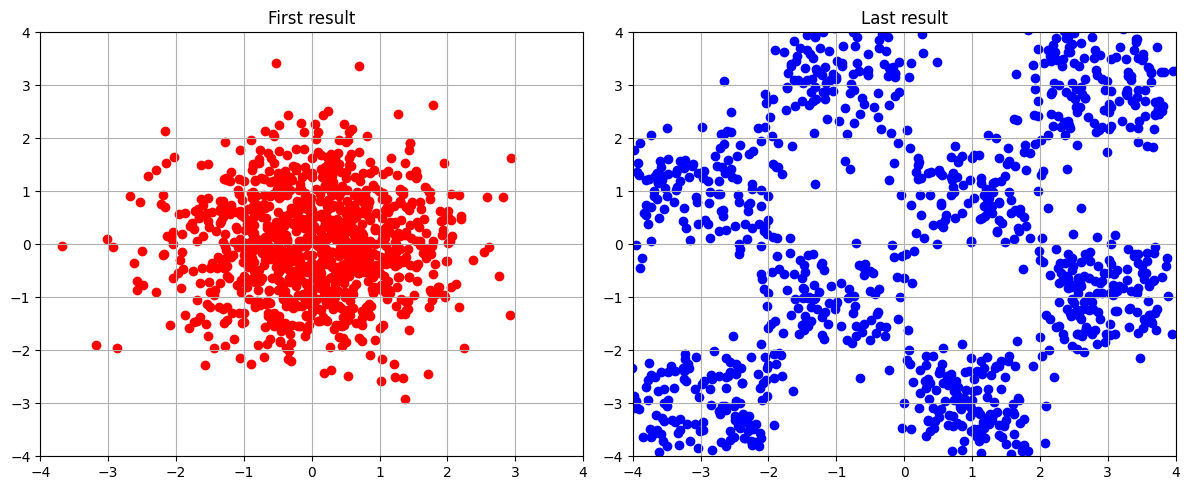

In [10]:
# Lấy result đầu tiên (giả sử là danh sách các điểm)
first_result = results[0]  # results[0] là list các điểm
last_result = results[-1]
# print(first_result)
# Nếu là tensor PyTorch


first_result_np = first_result.detach().cpu().numpy()
last_result_np = last_result.detach().cpu().numpy()

# Vẽ 2 hình cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ----- First result -----
axes[0].scatter(first_result_np[:,0], first_result_np[:,1], color='red')
axes[0].set_title("First result")
axes[0].set_xlim([-4, 4])
axes[0].set_ylim([-4, 4])
axes[0].grid(True)

# ----- Last result -----
axes[1].scatter(last_result_np[:,0], last_result_np[:,1], color='blue')
axes[1].set_title("Last result")
axes[1].set_xlim([-4, 4])
axes[1].set_ylim([-4, 4])
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
results_cpu_list = [r.detach().cpu().numpy() for r in results]
print(results_cpu_list[0])
frames = []

for i, results_cpu in enumerate(results_cpu_list):
    fig, ax = plt.subplots(figsize=(5,5))
    
    # Hiển thị toàn bộ batch tại thời điểm i
    ax.scatter(results_cpu[:,0], results_cpu[:,1], color='red', label=f'time step {i}')
    # ax.scatter(results_cpu[:,0], results_cpu[:,1], color='red', label=f'time step {i}')
    ax.legend()
    ax.set_title("ODE Sampling: Batch points over time")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    ax.set_xlim([-4, 4])
    ax.set_ylim([-4, 4])
    
    # Lưu figure vào buffer
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    image = buf.reshape((h, w, 4))  # 4 kênh RGBA
    frames.append(image)
    plt.close(fig)

# Tạo GIF
imageio.mimsave('ode_sampling_batch.gif', frames, duration=0.01)

[[-1.9107703  -0.13858344]
 [-0.8837227   0.8763845 ]
 [ 0.03754937  0.3429897 ]
 ...
 [ 2.3762743  -0.29531544]
 [-0.0730872  -0.5250333 ]
 [-2.044579    0.0063136 ]]


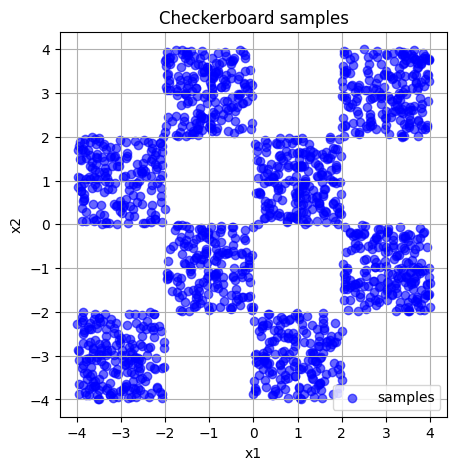

In [12]:
# Lấy dữ liệu
check_checker = sample_checkerboard(1500).cpu()

# Vẽ
plt.figure(figsize=(5,5))

# Chỉ cần scatter tất cả points
plt.scatter(check_checker[:,0], check_checker[:,1], color='blue', alpha=0.6, label='samples')

plt.title("Checkerboard samples")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.legend()
plt.show()